# 2D Image Decomposition

Decompose 2-D image data into **topologically simple** basis vectors using **Top-NMF** with a cubical complex.

We illustrate the method with two experiments:

1. **Synthetic data** -- overlapping mixtures of simple bar atoms. The ground truth is known, so we can directly compare Top-NMF and standard NMF in their ability to recover the underlying atoms when samples are heavily overlapping.
2. **(semi)Real-world fonts** -- glyph decomposition for Korean hangul, where ground truth is unknown but interpretable structure is expected.


## Setup

In [1]:
import os
from pathlib import Path

NOTEBOOK_CACHE_DIR = Path(".cache").resolve()
(NOTEBOOK_CACHE_DIR / "matplotlib").mkdir(parents=True, exist_ok=True)
(NOTEBOOK_CACHE_DIR / "fontconfig").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(NOTEBOOK_CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(NOTEBOOK_CACHE_DIR))
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import torch
from urllib.request import urlretrieve
from collections import deque
from typing import Dict, List, Optional, Tuple
from sklearn.decomposition import NMF

from TopNMF import (
    TopologicalNMF,
    CubicalComplex,
    target_diagram_loss,
    generate_ichimatsu_pattern,
    plot_gallery,
)
from TopNMF.visualization import FitMonitor

device = "cpu"



def fit_sparse_nmf_baseline(
    X_flat: np.ndarray,
    n_components: int,
    alpha: float = 0.05,
    random_state: int = 0,
    max_iter: int = 5000,
) -> Tuple[np.ndarray, np.ndarray]:
    """Fit an L1-regularized sparse-NMF baseline using scikit-learn.

    Parameters
    ----------
    X_flat : np.ndarray
        Non-negative sample-by-feature matrix.
    n_components : int
        Number of NMF components.
    alpha : float, optional
        L1 regularization strength on the component matrix.
    random_state : int, optional
        Random seed passed to scikit-learn.
    max_iter : int, optional
        Maximum number of coordinate-descent iterations.

    Returns
    -------
    W : np.ndarray
        Sample loadings.
    H : np.ndarray
        Sparse component matrix.
    """
    model = NMF(
        n_components=n_components,
        init="nndsvda",
        random_state=random_state,
        solver="cd",
        beta_loss="frobenius",
        alpha_W=0.0,
        alpha_H=alpha,
        l1_ratio=1.0,
        max_iter=max_iter,
        tol=1e-5,
    )
    W = model.fit_transform(X_flat)
    return W, model.components_



from scipy import ndimage as _ndimage


def basis_betti_counts(basis, image_shape, rel_threshold=0.3):
    """Mean Betti-0 (connected components) and Betti-1 (enclosed holes) per basis image.

    A topologically simple part has ``b0 = 1`` (single blob) and ``b1 = 0`` (no holes).
    Each basis is thresholded at ``rel_threshold * max`` before counting.
    """
    b0s, b1s = [], []
    for v in basis:
        img = np.asarray(v, dtype=float).reshape(image_shape)
        peak = img.max()
        if peak <= 0:
            b0s.append(0); b1s.append(0); continue
        mask = img > rel_threshold * peak
        if not mask.any():
            b0s.append(0); b1s.append(0); continue
        _, n_comp = _ndimage.label(mask)
        filled = _ndimage.binary_fill_holes(mask)
        _, n_holes = _ndimage.label(filled & ~mask)
        b0s.append(int(n_comp)); b1s.append(int(n_holes))
    return float(np.mean(b0s)), float(np.mean(b1s))

def _row_normalize(M):
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    return M / np.where(norms > 0, norms, 1.0)


def atom_recovery_score(V_est, atoms_true):
    A_est = _row_normalize(V_est.reshape(V_est.shape[0], -1))
    A_true = _row_normalize(atoms_true.reshape(atoms_true.shape[0], -1))
    cost = -A_est @ A_true.T
    row, col = linear_sum_assignment(cost)
    return float(-cost[row, col].mean())


def reconstruction_rmse(X_flat, basis):
    # Non-negative least squares on the basis to fit each sample.
    from scipy.optimize import nnls
    rmses = []
    B = basis.reshape(basis.shape[0], -1)
    for x in X_flat:
        u, _ = nnls(B.T, x)
        rmses.append(np.sqrt(np.mean((B.T @ u - x) ** 2)))
    return float(np.mean(rmses))


[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


---
## Synthetic example: decomposing overlapping atoms

We construct a controlled mixture problem in which the ground-truth atoms are
**single connected components** (topologically simple, $b_0=1$, $b_1=0$), but each
sample is a sum of several atoms whose supports overlap. Combinations of multiple
horizontal and vertical bars yield grid-shaped samples with multiple connected
components and enclosed holes -- topologically rich data built from topologically
simple parts.

We deliberately use a *limited* number of training samples with heavy overlap.
Standard NMF, having no incentive to keep each basis vector connected, mixes
overlapping atoms and leaks "ghost" intersection pixels into individual bases.
Top-NMF, with an empty target persistence diagram, drives every basis vector
toward the topologically simplest shape and recovers the ground-truth atoms
even under this small-sample regime.


### Generate synthetic data


Ground-truth atoms: (6, 12, 12)  (each is a single connected bar)
Samples: (30, 12, 12)


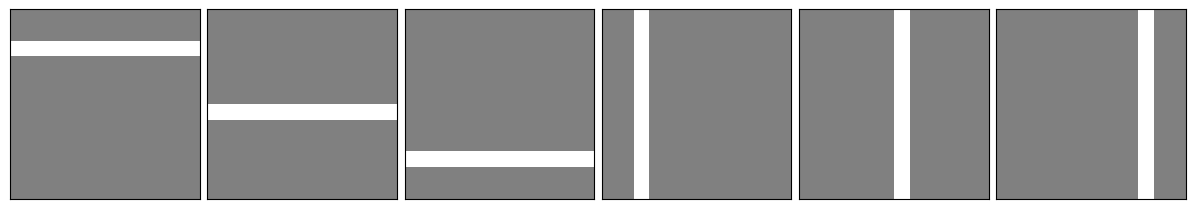

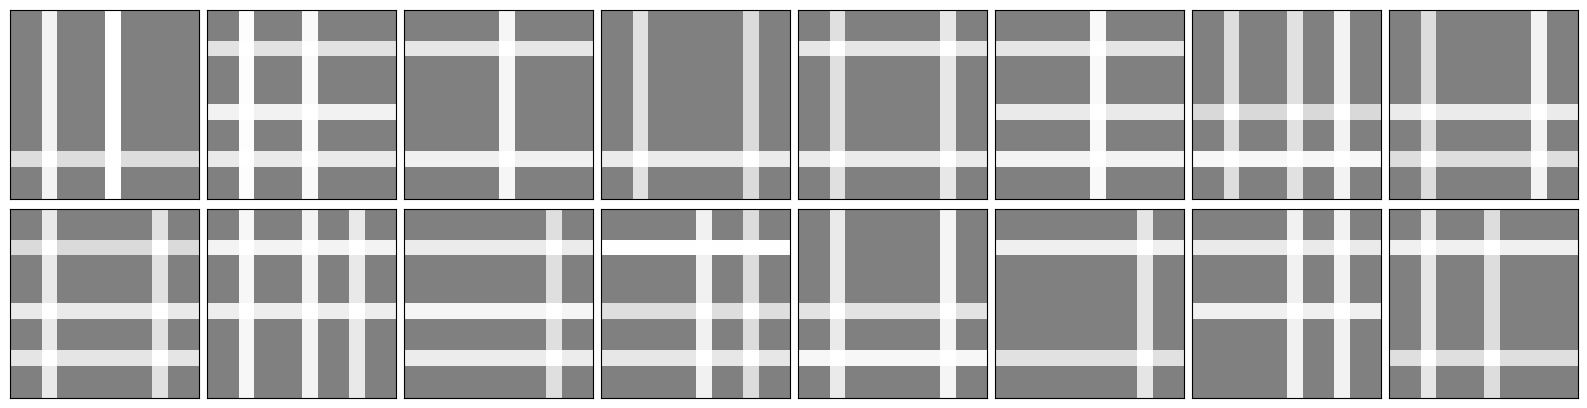

In [2]:
# Ground-truth atoms: thin horizontal/vertical bars on a 12x12 grid.
# Each atom is a single connected component (b_0 = 1, b_1 = 0).
# Sums of multiple atoms produce grid-like samples with non-trivial topology
# (multiple components when parallel bars are picked, enclosed holes when
# horizontal and vertical bars cross).

image_shape_synth = (12, 12)
h_rows = (2, 6, 9)
v_cols = (2, 6, 9)

def make_bar_atoms(image_shape, h_rows, v_cols):
    H, W = image_shape
    atoms = []
    labels = []
    for r in h_rows:
        a = np.zeros((H, W), dtype=np.float32)
        a[r, :] = 1.0
        atoms.append(a); labels.append(f"H@row{r}")
    for c in v_cols:
        a = np.zeros((H, W), dtype=np.float32)
        a[:, c] = 1.0
        atoms.append(a); labels.append(f"V@col{c}")
    return np.stack(atoms, axis=0), labels

def generate_overlap_samples(atoms, num_samples=30, min_k=3, max_k=5,
                             weight_range=(0.7, 1.0), seed=42):
    rng = np.random.default_rng(seed)
    K, H, W = atoms.shape
    samples = np.zeros((num_samples, H, W), dtype=np.float32)
    for i in range(num_samples):
        k = rng.integers(min_k, max_k + 1)
        idx = rng.choice(K, size=int(k), replace=False)
        weights = rng.uniform(*weight_range, size=int(k)).astype(np.float32)
        samples[i] = (atoms[idx] * weights[:, None, None]).sum(axis=0)
    return np.clip(samples, 0.0, 1.0)

ground_truth_atoms, atom_labels = make_bar_atoms(image_shape_synth, h_rows, v_cols)
n_components_synth = ground_truth_atoms.shape[0]
print(f"Ground-truth atoms: {ground_truth_atoms.shape}  (each is a single connected bar)")

# We deliberately use a small number of samples (30) with 3--5 atoms each so
# that overlap is heavy and the problem is not trivially solved by
# least-squares NMF alone.
X_synth = generate_overlap_samples(
    ground_truth_atoms, num_samples=30, min_k=3, max_k=5, seed=42,
)
X_synth_flat = X_synth.reshape(X_synth.shape[0], -1)
print(f"Samples: {X_synth.shape}")

_ = plot_gallery(ground_truth_atoms,
                 #title="Ground-truth atoms",
                 n_row=1, n_col=n_components_synth)
_ = plot_gallery(X_synth[:16],
                 #title="Samples (random overlapping mixtures of atoms)",
                 n_row=2, n_col=8)


### Fit Top-NMF
We use a vertex-based superlevel cubical complex and an empty target persistence
diagram so that each basis vector is pushed toward a single connected blob with
no holes.


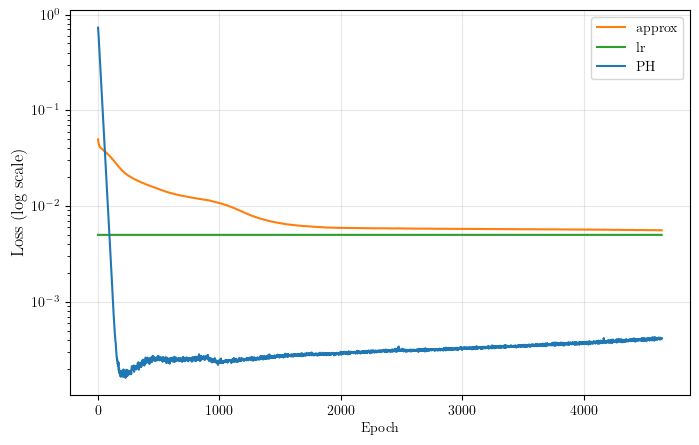

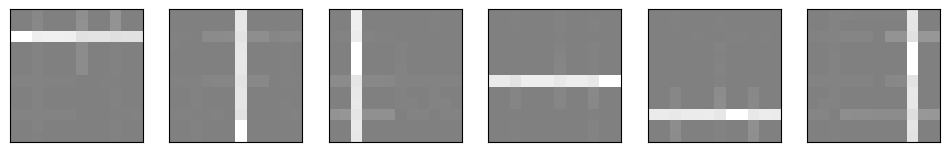

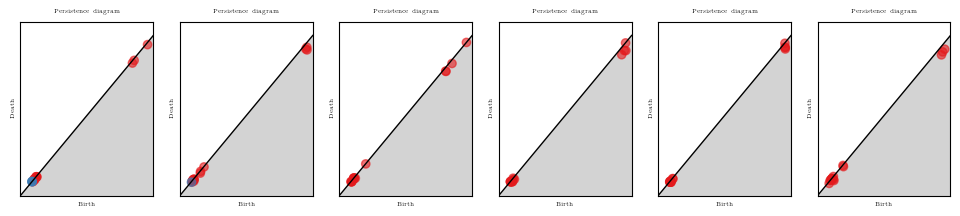

  0%|          | 0/5000 [00:00<?, ?it/s]

Final reconstruction loss: 0.0055


In [3]:
cubical_synth = CubicalComplex(superlevel=True, dim=len(image_shape_synth), mode="V")

target_diagrams_synth = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

model_synth = TopologicalNMF(
    n_components=n_components_synth,
    device=device,
    complex=cubical_synth,
    ph_loss_fn=target_diagram_loss,
    data_shape=image_shape_synth,
    use_embedding=False,
    random_state=42,
)

monitor_synth = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=50,
    grid=(1, n_components_synth),
    PHmode="V",
    superlevel=True,
    save_video=True,
)

model_synth.fit(
    X_synth_flat,
    n_iterations=5000,
    lr=0.005,
    lambda_top=1.0,
    weight_decay=0.1,
    PH_dims=[0, 1],
    start_epoch_topological=0,
    verbose=True,
    target_diagrams=target_diagrams_synth,
    init_method="nndsvdar",
    monitor=monitor_synth,
)

V_synth = model_synth.V.detach().cpu().numpy()
print(f"Final reconstruction loss: {model_synth.losses['approx'][-1]:.4f}")
plt.close("all")


In [4]:
monitor_synth.save("synthetic_bars.mp4", show=["basis", "PH"], fps=5)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2400, 225) to (2400, 240) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved: synthetic_bars.mp4


### Compare with standard NMF
With the same number of components, standard NMF mixes overlapping atoms and
typically returns grid-like or fragmented bases. Top-NMF recovers the
ground-truth single-bar atoms much more cleanly. The atom-recovery score below
is the mean cosine similarity between recovered bases and ground-truth atoms
under the optimal permutation.


Atom-recovery score (mean cosine similarity, higher = better):
  Top-NMF       : 0.989
  Standard NMF  : 0.841
Reconstruction RMSE on training samples (lower = better fit):
  Top-NMF       : 0.0733
  Standard NMF  : 0.0544


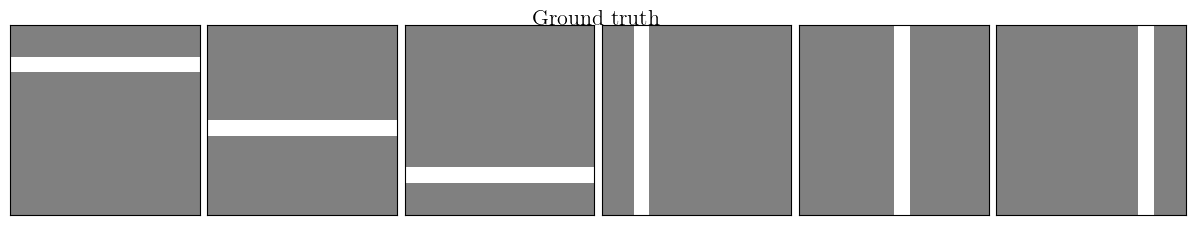

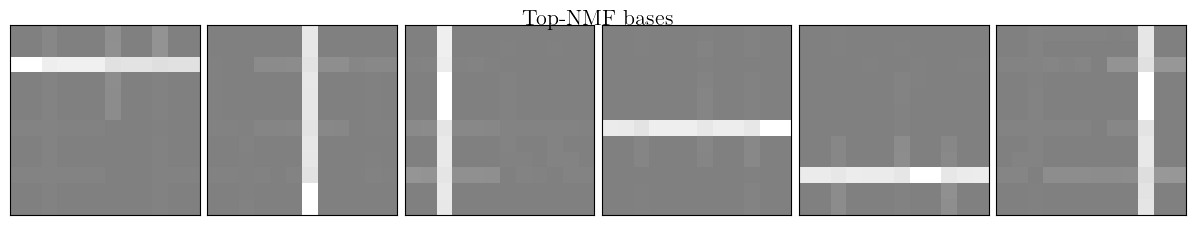

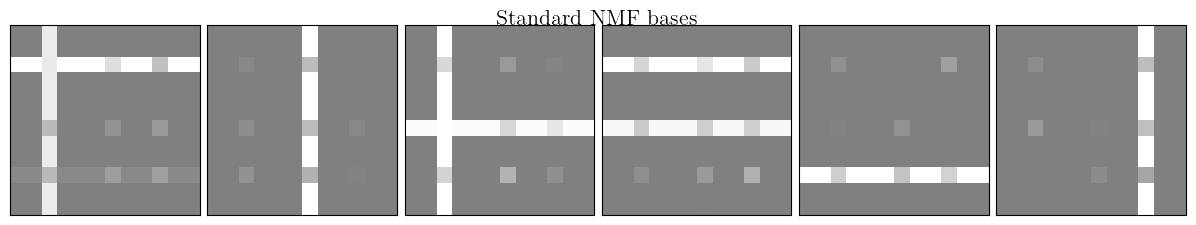

In [ ]:
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment

nmf_synth = NMF(n_components=n_components_synth, init="nndsvda",
                random_state=0, max_iter=5000)
nmf_synth.fit(X_synth_flat)
V_synth_std = nmf_synth.components_

_ = plot_gallery(ground_truth_atoms,
                 title="Ground truth", n_row=1, n_col=n_components_synth)
_ = plot_gallery(V_synth.reshape(-1, *image_shape_synth),
                 title="Top-NMF bases", n_row=1, n_col=n_components_synth)
_ = plot_gallery(V_synth_std.reshape(-1, *image_shape_synth),
                 title="Standard NMF bases",
                 n_row=1, n_col=n_components_synth)


print("Atom-recovery score (mean cosine similarity, higher = better):")
print(f"  Top-NMF       : {atom_recovery_score(V_synth, ground_truth_atoms):.3f}")
print(f"  Standard NMF  : {atom_recovery_score(V_synth_std, ground_truth_atoms):.3f}")

print("Reconstruction RMSE on training samples (lower = better fit):")
print(f"  Top-NMF       : {reconstruction_rmse(X_synth_flat, V_synth):.4f}")
print(f"  Standard NMF  : {reconstruction_rmse(X_synth_flat, V_synth_std):.4f}")


### Sparse NMF baseline

For images, standard NMF is complemented by an L1-regularized sparse NMF baseline from scikit-learn.


Atom-recovery score (mean cosine similarity, higher = better):
  Top-NMF              : 0.989
  Standard NMF         : 0.841
  Sparse NMF           : 0.767
Reconstruction RMSE on training samples (lower = better fit):
  Top-NMF              : 0.0733
  Standard NMF         : 0.0544
  Sparse NMF           : 0.0803


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 5000 reached. Increase it to improve convergence.
  warnings.warn(


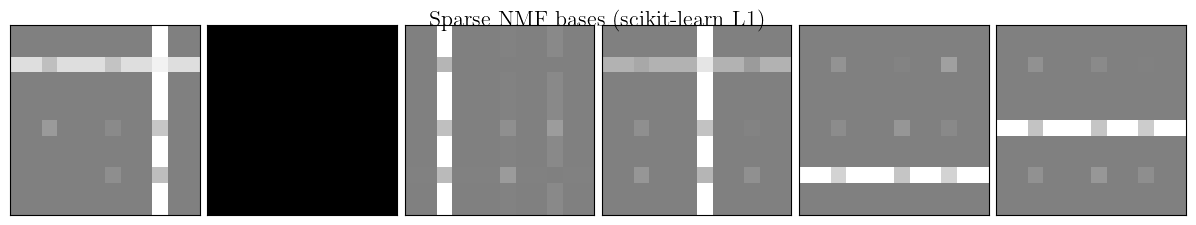

In [6]:
W_synth_sparse, V_synth_sparse = fit_sparse_nmf_baseline(
    X_synth_flat,
    n_components_synth,
    alpha=0.02,
    random_state=0,
)

_ = plot_gallery(
    V_synth_sparse.reshape(-1, *image_shape_synth),
    title="Sparse NMF bases (scikit-learn L1)",
    n_row=1,
    n_col=n_components_synth,
)

print("Atom-recovery score (mean cosine similarity, higher = better):")
print(f"  Top-NMF              : {atom_recovery_score(V_synth, ground_truth_atoms):.3f}")
print(f"  Standard NMF         : {atom_recovery_score(V_synth_std, ground_truth_atoms):.3f}")
print(f"  Sparse NMF           : {atom_recovery_score(V_synth_sparse, ground_truth_atoms):.3f}")

print("Reconstruction RMSE on training samples (lower = better fit):")
print(f"  Top-NMF              : {reconstruction_rmse(X_synth_flat, V_synth):.4f}")
print(f"  Standard NMF         : {reconstruction_rmse(X_synth_flat, V_synth_std):.4f}")
print(f"  Sparse NMF           : {reconstruction_rmse(X_synth_flat, V_synth_sparse):.4f}")


#### Consolidated metric summary

In [7]:
# Consolidated metric summary -- synthetic bars (ground-truth atoms known)
import pandas as pd
from IPython.display import display

methods_synth = [
    ("Top-NMF", V_synth),
    ("Standard NMF", V_synth_std),
    ("Sparse NMF", V_synth_sparse),
]

rows_synth = []
for name, Vm in methods_synth:
    b0, b1 = basis_betti_counts(Vm, image_shape_synth)
    rows_synth.append({
        "method": name,
        "recon RMSE": reconstruction_rmse(X_synth_flat, Vm),
        "atom recovery (cos)": atom_recovery_score(Vm, ground_truth_atoms),
        "mean b0 (target 1)": b0,
        "mean b1 (target 0)": b1,
    })
summary_synth = pd.DataFrame(rows_synth).set_index("method")
print("Synthetic bars -- the true atoms are single connected bars (b0=1, b1=0). Top-NMF targets an")
print("empty diagram so bases stay connected and hole-free while still recovering the atoms.")
print("Reconstruction RMSE uses the optimal non-negative coefficients (lower = better).")
display(summary_synth.round(4))


Synthetic bars -- the true atoms are single connected bars (b0=1, b1=0). Top-NMF targets an
empty diagram so bases stay connected and hole-free while still recovering the atoms.
Reconstruction RMSE uses the optimal non-negative coefficients (lower = better).


,recon RMSE,atom recovery (cos),mean b0 (target 1),mean b1 (target 0)
method,,,,
Top-NMF,0.0733,0.9888,1.0000,0.0
Standard NMF,0.0544,0.8413,1.6667,0.0
Sparse NMF,0.0803,0.7675,1.0000,0.0


---
## Font glyphs

We now apply Top-NMF to datasets where interpretable structure -- strokes
shared across many glyphs -- is expected. 


In [3]:
# Download a CJK font for extracting real glyph components
font_file = "NotoSansCJKjp-Regular.otf"
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
font_path = os.path.join(base_dir, font_file)

if not os.path.exists(font_path):
    url = "https://raw.githubusercontent.com/notofonts/noto-cjk/main/Sans/OTF/Japanese/NotoSansCJKjp-Regular.otf"
    urlretrieve(url, font_path)
    print("Font downloaded:", font_path)
else:
    print("Using existing font:", font_path)

Using existing font: /Users/kaji/Library/CloudStorage/Dropbox/maple/TopNMF/notebook/NotoSansCJKjp-Regular.otf


#### Consolidated metric summary

### Hangul: stroke decomposition
Hangul characters decompose into reusable jamo-like strokes. We add a small
amount of intensity variation to demonstrate robustness.


#### Generate Hangul character images


In [15]:
# Download the Nanum Gothic font for rendering Hangul characters
if not os.path.exists("NanumGothicCoding-Regular.ttf"):
    url = "https://github.com/google/fonts/raw/main/ofl/nanumgothiccoding/NanumGothicCoding-Regular.ttf"
    urlretrieve(url, "NanumGothicCoding-Regular.ttf")
    print("Font downloaded.")

In [8]:
labels_hangul = ['가','다','라','갸','댜','랴']
images_array, labels = generate_font_images(labels_hangul, 'NanumGothicCoding-Regular.ttf', font_size=48)
print(f"Generated {len(labels)} images, shape: {images_array.shape}")


Generated 6 images, shape: (6, 64, 64)


Data: (6, 64, 64)


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

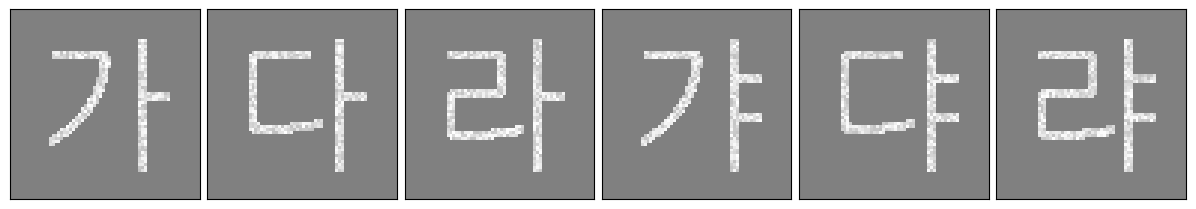

In [9]:
# Binarize and add random intensity variation
X_hangul = (images_array > 127).astype(np.float32)
X_hangul *= np.random.uniform(low=0.5, high=1.0, size=X_hangul.shape)

n_components_hangul = 5
data_dims_hangul = X_hangul.shape[1:]  # (64, 64)

print(f"Data: {X_hangul.shape}")
plot_gallery(X_hangul, n_row=1, n_col=6)

#### Fit Top-NMF


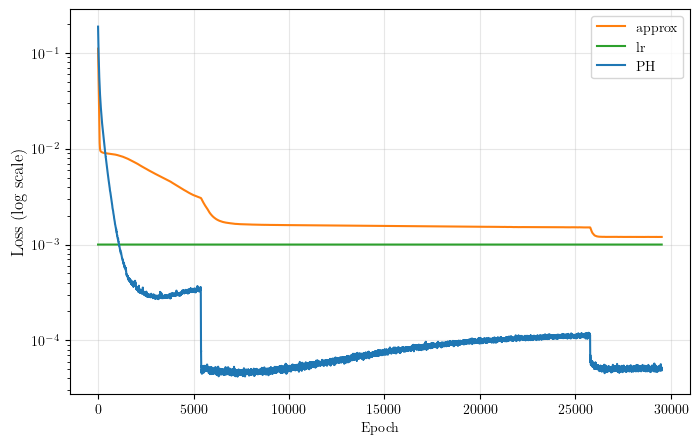

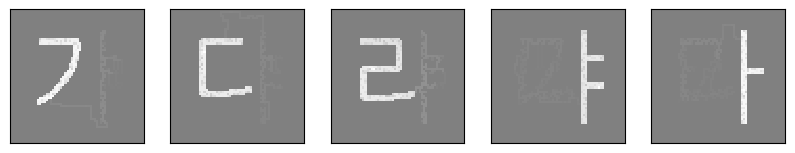

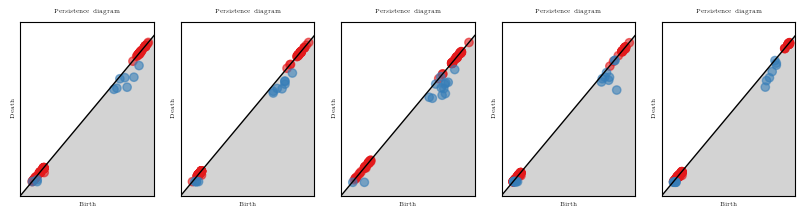

  0%|          | 0/30000 [00:00<?, ?it/s]

Final reconstruction loss: 0.0012


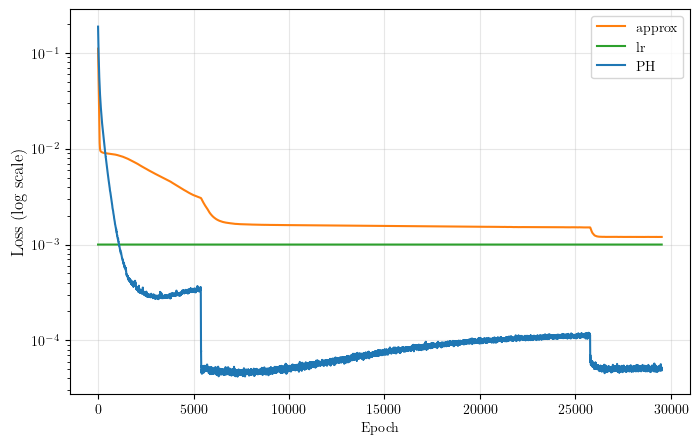

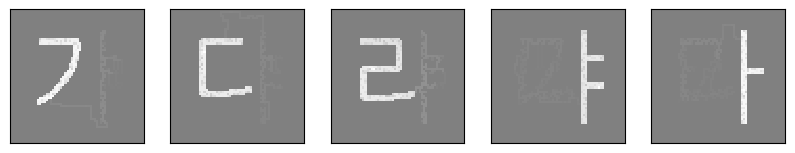

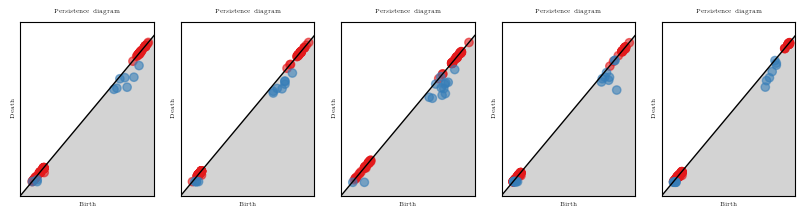

In [ ]:
# Empty target diagrams encourage topologically simple bases
target_diagrams_hangul = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

# Vertex-based superlevel cubical complex for 2-D images
cubical_hangul = CubicalComplex(superlevel=True, dim=len(data_dims_hangul), mode="V")

model_hangul = TopologicalNMF(
    n_components=n_components_hangul,
    device=device,
    random_state=42,
    complex=cubical_hangul,
    ph_loss_fn=target_diagram_loss,
    data_shape=data_dims_hangul,
    use_embedding=False,
    #recon_loss="wasserstein",
)

monitor_hangul = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=10,
    grid=(1, 5),
    PHmode="V",
    superlevel=True,
)

# Flatten spatial dims for NMF: (n_samples, n_features)
X_hangul_flat = X_hangul.reshape(X_hangul.shape[0], -1)

model_hangul.fit(
    X_hangul_flat,
    n_iterations=30000,
    lr=0.001,
    PH_dims=[0],
    lambda_top=0.7,
    weight_decay=0.2,
    verbose=True,
    target_diagrams=target_diagrams_hangul,
    init_method="nndsvda",
    monitor=monitor_hangul,
)

V_hangul = model_hangul.V.detach().cpu().numpy()
print(f"Final reconstruction loss: {model_hangul.losses['approx'][-1]:.4f}")

#### Compare with standard NMF


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

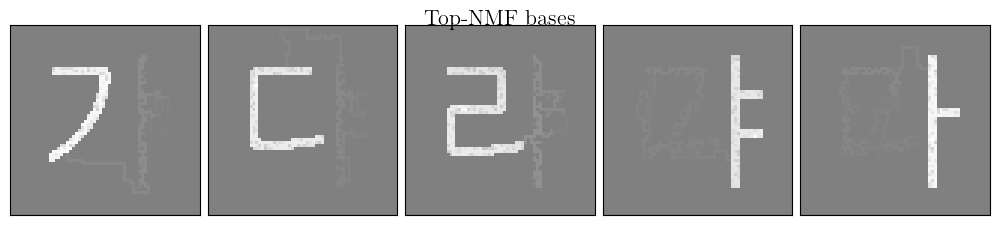

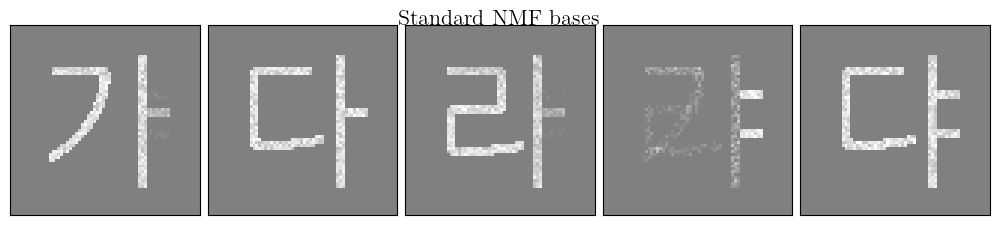

In [19]:
from sklearn.decomposition import NMF

# Top-NMF basis vectors
plot_gallery(V_hangul.reshape(-1, *data_dims_hangul), title="Top-NMF bases", n_row=1, n_col=5)

# Standard NMF for comparison
nmf = NMF(n_components=n_components_hangul, init="nndsvda", random_state=0)
nmf.fit_transform(X_hangul_flat)
H_std = nmf.components_

plot_gallery(H_std.reshape(-1, *data_dims_hangul), title="Standard NMF bases", n_row=1, n_col=5)

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 5000 reached. Increase it to improve convergence.
  warnings.warn(


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

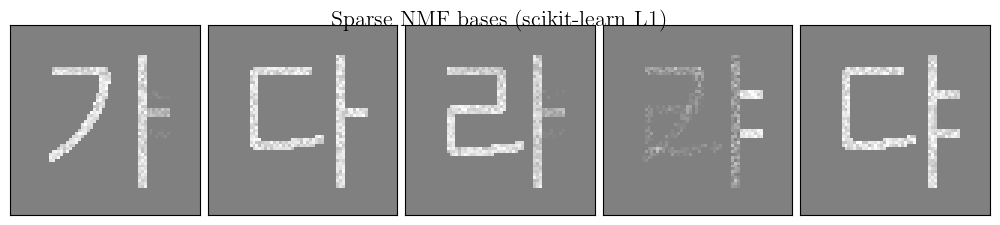

In [20]:
W_hangul_sparse, H_hangul_sparse = fit_sparse_nmf_baseline(
    X_hangul_flat,
    n_components_hangul,
    alpha=0.01,
    random_state=1,
)

plot_gallery(
    H_hangul_sparse.reshape(-1, *data_dims_hangul),
    title="Sparse NMF bases (scikit-learn L1)",
    n_row=1,
    n_col=5,
)


#### Consolidated metric summary

In [21]:
# Consolidated metric summary -- Hangul glyphs (no ground-truth atoms)
import pandas as pd
from IPython.display import display

methods_hangul = [
    ("Top-NMF", V_hangul),
    ("Standard NMF", H_std),
    ("Sparse NMF", H_hangul_sparse),
]

rows_hangul = []
for name, Vm in methods_hangul:
    b0, b1 = basis_betti_counts(Vm, data_dims_hangul)
    rows_hangul.append({
        "method": name,
        "recon RMSE": reconstruction_rmse(X_hangul_flat, Vm),
        "mean b0 (components)": b0,
        "mean b1 (holes)": b1,
    })
summary_hangul = pd.DataFrame(rows_hangul).set_index("method")
print("Hangul -- no ground-truth atoms; reusable jamo-like strokes are expected. Lower b0/b1 means")
print("cleaner, topologically simpler strokes. Reconstruction RMSE uses optimal NNLS coefficients.")
display(summary_hangul.round(4))


Hangul -- no ground-truth atoms; reusable jamo-like strokes are expected. Lower b0/b1 means
cleaner, topologically simpler strokes. Reconstruction RMSE uses optimal NNLS coefficients.


,recon RMSE,mean b0 (components),mean b1 (holes)
method,,,
Top-NMF,0.0346,1.0,0.0
Standard NMF,0.0228,9.2,0.2
Sparse NMF,0.0227,9.2,0.2
